In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Configuration d'affichage et chemins projet
sns.set_theme(style="whitegrid", context="notebook")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
GOLD_PATH = ROOT / "data" / "gold" / "model_dataset_monthly.csv"
FIG_DIR = ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

if not GOLD_PATH.exists():
    raise FileNotFoundError(f"Gold dataset introuvable : {GOLD_PATH}")

# Chargement du Gold dataset avec fréquence mensuelle explicite
df = pd.read_csv(GOLD_PATH, parse_dates=["month"], index_col="month")
df.index = pd.DatetimeIndex(df.index, freq="MS")
print(f"Shape : {df.shape}")
print(f"Plage : {df.index.min().date()} -> {df.index.max().date()}")
display(df.head())


Shape : (96, 29)
Plage : 2017-01-01 -> 2024-12-01


,ipc_level,inflation_mom,inflation_yoy,publication_date,trends_prix_alim,trends_inflation,trends_carburant,trends_subvention,trends_composite,behavioral_index_pure,...,inflation_yoy_lag1,inflation_yoy_lag2,inflation_mom_lag1,inflation_mom_lag2,target_inflation_yoy_t1,target_high_inflation_regime_t1,target_ipc_level_t1,as_of_date,feature_available_at,split_label
month,,,,,,,,,,,,,,,,,,,,,
2017-01-01,98.6,NaN,NaN,2017-02-20,0.356644,0.302863,NaN,NaN,0.329753,0.313947,...,NaN,NaN,NaN,NaN,NaN,NaN,98.8,2017-01-31,2017-02-01,train_A|train_B
2017-02-01,98.8,0.202840,NaN,2017-03-20,0.402666,0.467773,NaN,NaN,0.435220,0.425160,...,NaN,NaN,NaN,NaN,NaN,NaN,98.1,2017-02-28,2017-03-01,train_A|train_B
2017-03-01,98.1,-0.708502,NaN,2017-04-20,0.503236,0.456913,NaN,NaN,0.480074,0.472459,...,NaN,NaN,0.202840,NaN,NaN,NaN,98.4,2017-03-31,2017-04-01,train_A|train_B
2017-04-01,98.4,0.305810,NaN,2017-05-20,0.485194,0.504952,NaN,NaN,0.495073,0.488275,...,NaN,NaN,-0.708502,0.202840,NaN,NaN,99.5,2017-04-30,2017-05-01,train_A|train_B
2017-05-01,99.5,1.117886,NaN,2017-06-20,0.507083,0.519765,NaN,NaN,0.513424,0.507626,...,NaN,NaN,0.305810,-0.708502,NaN,NaN,100.5,2017-05-31,2017-06-01,train_A|train_B


In [2]:
# Statistiques descriptives de toutes les features numériques
numeric_df = df.select_dtypes(include=[np.number]).copy()
desc = numeric_df.describe().T
desc["missing_pct"] = 100 * numeric_df.isna().mean()
desc = desc.sort_index()
display(desc)


,count,mean,std,min,25%,50%,75%,max,missing_pct
behavioral_index_pure,96.0,0.581850,0.217000,0.229937,0.394050,0.541077,0.794609,1.000000,0.000000
behavioral_index_pure_lag1,95.0,0.579438,0.216854,0.229937,0.392768,0.539529,0.791082,1.000000,1.041667
behavioral_index_pure_lag2,94.0,0.578048,0.217591,0.229937,0.391486,0.535849,0.791511,1.000000,2.083333
inflation_mom,95.0,0.295863,1.314899,-2.495202,-0.468788,0.233827,1.034683,4.091342,1.041667
inflation_mom_lag1,94.0,0.301470,1.320808,-2.495202,-0.501570,0.269819,1.046188,4.091342,2.083333
inflation_mom_lag2,93.0,0.308837,1.326023,-2.495202,-0.534351,0.305810,1.057692,4.091342,3.125000
inflation_yoy,84.0,3.892390,5.939508,-2.737048,-0.336345,1.529821,7.025205,20.837298,12.500000
inflation_yoy_lag1,83.0,3.931797,5.964557,-2.737048,-0.381710,1.648352,7.245430,20.837298,13.541667
inflation_yoy_lag2,82.0,3.971231,5.990366,-2.737048,-0.427076,1.796182,7.465656,20.837298,14.583333
ipc_level,96.0,109.723958,12.048776,98.100000,100.875000,102.650000,120.900000,131.700000,0.000000


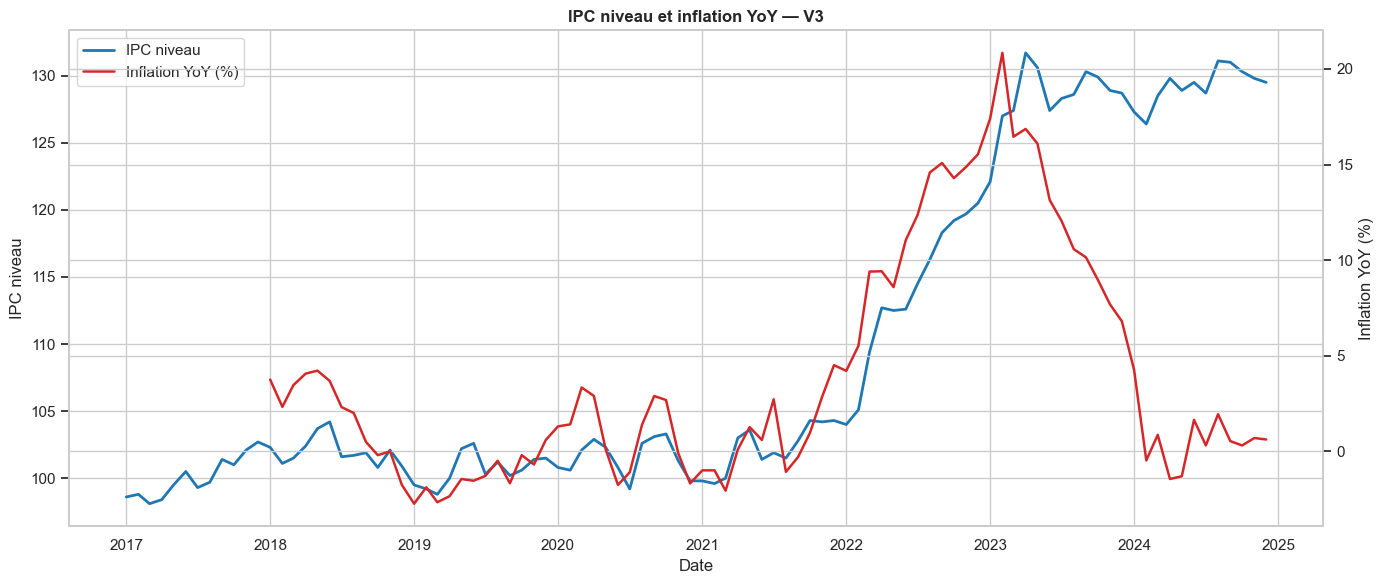

In [3]:
# Tracé IPC niveau + inflation YoY sur 2010-2024 (ou plage disponible du dataset)
required_cols = [c for c in ["ipc_level", "inflation_yoy"] if c in df.columns]
if len(required_cols) < 2:
    raise KeyError(f"Colonnes requises absentes pour le tracé IPC/YoY : {required_cols}")

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

ax1.plot(df.index, df["ipc_level"], color="#1f77b4", linewidth=2.0, label="IPC niveau")
ax2.plot(df.index, df["inflation_yoy"], color="#d62728", linewidth=1.8, label="Inflation YoY (%)")

ax1.set_title("IPC niveau et inflation YoY — V3", fontweight="bold")
ax1.set_xlabel("Date")
ax1.set_ylabel("IPC niveau")
ax2.set_ylabel("Inflation YoY (%)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

fig.tight_layout()
fig.savefig(FIG_DIR / "nb01_ipc_inflation_v3.png", dpi=150, bbox_inches="tight")
display(fig)
plt.close(fig)


,lag,correlation
0,0,0.535471
1,1,0.550349
2,2,0.555674
3,3,0.564980
4,4,0.577095
5,5,0.587002
6,6,0.601532


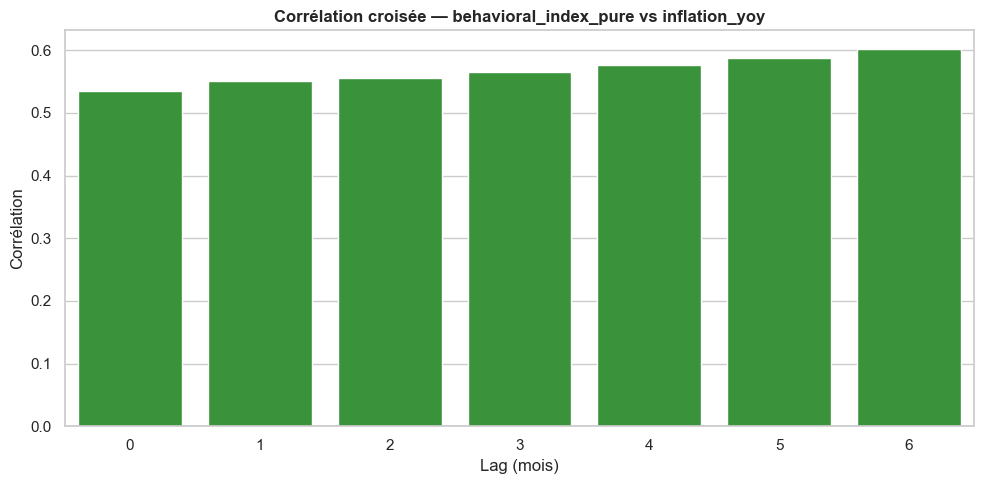

In [4]:
# Corrélation croisée behavioral_index_pure vs inflation_yoy pour les lags 0 à 6
if "behavioral_index_pure" not in df.columns or "inflation_yoy" not in df.columns:
    raise KeyError("behavioral_index_pure et/ou inflation_yoy absents du Gold dataset")

common = df[["behavioral_index_pure", "inflation_yoy"]].dropna().copy()
common.index = pd.DatetimeIndex(common.index, freq="MS")
lags = list(range(0, 7))
corrs = []
for lag in lags:
    if lag == 0:
        corr = common["behavioral_index_pure"].corr(common["inflation_yoy"])
    else:
        corr = common["behavioral_index_pure"].iloc[:-lag].corr(common["inflation_yoy"].iloc[lag:])
    corrs.append(corr)

lag_df = pd.DataFrame({"lag": lags, "correlation": corrs})
display(lag_df)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=lag_df, x="lag", y="correlation", color="#2ca02c", ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Corrélation croisée — behavioral_index_pure vs inflation_yoy", fontweight="bold")
ax.set_xlabel("Lag (mois)")
ax.set_ylabel("Corrélation")
fig.tight_layout()
fig.savefig(FIG_DIR / "nb01_behavioral_ccf_v3.png", dpi=150, bbox_inches="tight")
display(fig)
plt.close(fig)


In [5]:
# Tracé hybrid_macro_index vs inflation_yoy si la colonne existe
if "hybrid_macro_index" in df.columns and "inflation_yoy" in df.columns:
    sub = df[["hybrid_macro_index", "inflation_yoy"]].dropna().copy()
    sub.index = pd.DatetimeIndex(sub.index, freq="MS")

    fig, ax1 = plt.subplots(figsize=(14, 5))
    ax2 = ax1.twinx()
    ax1.plot(sub.index, sub["hybrid_macro_index"], color="#ff7f0e", linewidth=2.0, label="Hybrid macro index")
    ax2.plot(sub.index, sub["inflation_yoy"], color="#9467bd", linewidth=1.6, label="Inflation YoY (%)")
    ax1.set_title("Hybrid macro index vs inflation_yoy", fontweight="bold")
    ax1.set_xlabel("Date")
    ax1.set_ylabel("Hybrid macro index")
    ax2.set_ylabel("Inflation YoY (%)")
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "nb01_hybrid_vs_yoy_v3.png", dpi=150, bbox_inches="tight")
    display(fig)
    plt.close(fig)
else:
    print("hybrid_macro_index absent du Gold dataset : tracé ignoré.")


hybrid_macro_index absent du Gold dataset : tracé ignoré.


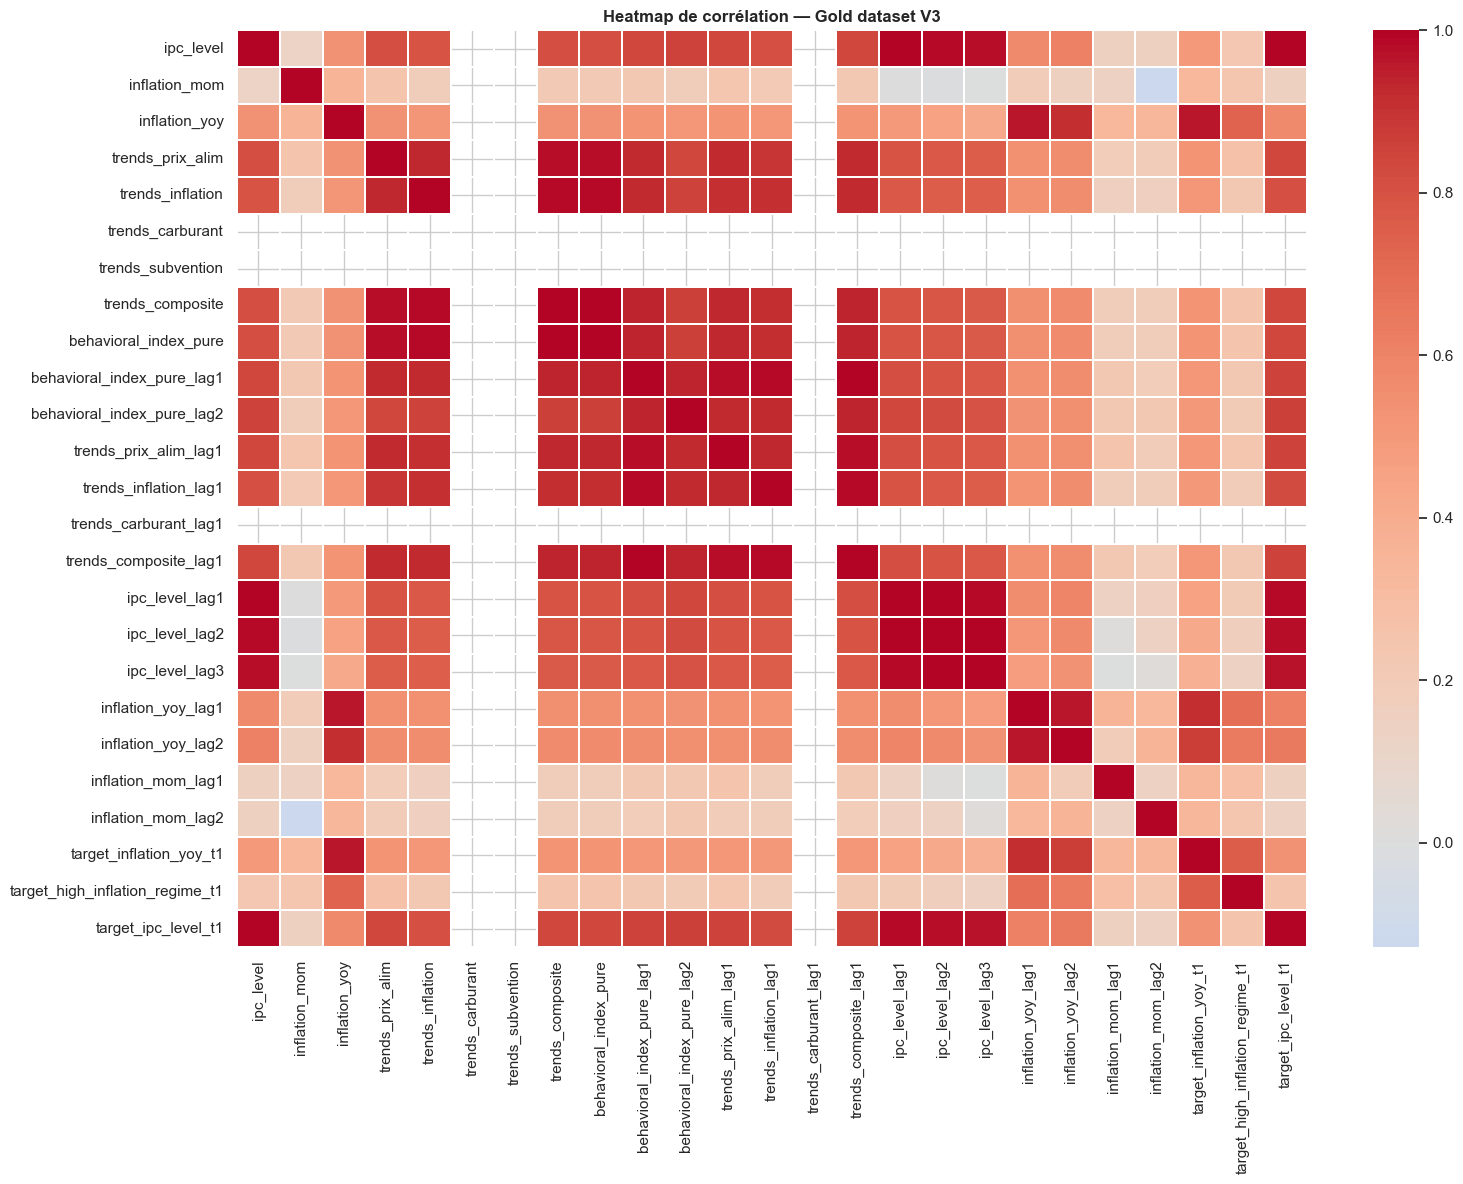

In [6]:
# Heatmap de corrélation des features numériques du Gold dataset
corr = numeric_df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.3, ax=ax)
ax.set_title("Heatmap de corrélation — Gold dataset V3", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "nb01_gold_corr_heatmap_v3.png", dpi=150, bbox_inches="tight")
display(fig)
plt.close(fig)


,split_label,n
0,train_A|train_B,36
1,test_B,36
2,test_A|train_B,24


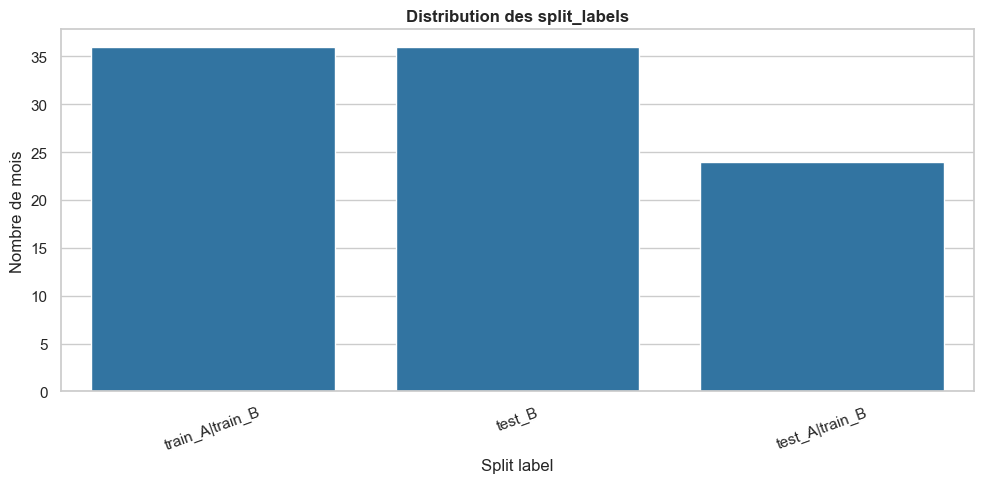

In [7]:
# Distribution des split_labels
if "split_label" not in df.columns:
    raise KeyError("split_label absent du Gold dataset")

split_counts = df["split_label"].fillna("missing").value_counts().rename_axis("split_label").reset_index(name="n")
display(split_counts)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=split_counts, x="split_label", y="n", color="#1f77b4", ax=ax)
ax.set_title("Distribution des split_labels", fontweight="bold")
ax.set_xlabel("Split label")
ax.set_ylabel("Nombre de mois")
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
fig.savefig(FIG_DIR / "nb01_split_distribution_v3.png", dpi=150, bbox_inches="tight")
display(fig)
plt.close(fig)
